In [24]:
#数据的导入
import numpy as np
import pandas as pd
from pandas.io.pytables import dropna_doc

df = pd.read_csv('employees_raw.csv')
#print(type(df))
#print(df.tail())
#print(df.salary.mean())
#数据的导出
df.to_csv('new.csv')

#json
import json
'''
with open('departments.json', 'r', encoding='utf-8') as f: # 改成 'r'
    departments = json.load(f) # 去掉 s
#print(departments)
#print(type(df))
#df = pd.DataFrame(departments)
'''

# 1. 读取你的 departments.json
with open('departments.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. 打印行和列（管理器 manager 会显示成字典）
df = pd.DataFrame(data)
print("--- 普通版（行和列） ---")
print(df)

# 3. 如果你想把 manager 里的 name 和 email 也拆成清晰的列
df_flat = pd.json_normalize(data)
print("\n--- 完美版（把嵌套拆开） ---")
print(df_flat)






--- 普通版（行和列） ---
   dept_id   dept_name                                            manager  \
0       90   Executive  {'name': 'Steven King', 'email': 'sking@compan...   
1       60          IT  {'name': 'Alexander Hunold', 'email': 'ahunold...   
2      100     Finance  {'name': 'Nancy Greenberg', 'email': 'ngreenbe...   
3       30  Purchasing  {'name': 'Den Raphaely', 'email': 'draphael@co...   

    location  
0    Seattle  
1  Southlake  
2    Seattle  
3    Seattle  

--- 完美版（把嵌套拆开） ---
   dept_id   dept_name   location      manager.name         manager.email
0       90   Executive    Seattle       Steven King     sking@company.com
1       60          IT  Southlake  Alexander Hunold   ahunold@company.com
2      100     Finance    Seattle   Nancy Greenberg  ngreenbe@company.com
3       30  Purchasing    Seattle      Den Raphaely  draphael@company.com


In [47]:
import pandas as pd
import numpy as np

s = pd.Series([1,2,np.nan,np.nan,np.nan],dtype=float)
df = pd.DataFrame({
    'A': [1, 2, np.nan],  # 每一列单独声明，干净利落
    'B': [np.nan, 3, 4],
    'C': [2, 5, 6]
})
print(s)
#查看是否为缺失值
print(s.isna())
#print(s.isnull)
#print(df.isnull())
print(df.isna())
print(df.isna().sum())
print(s.isna().sum())#查看缺失值个数

print('-'*30)
#删除缺失值
print(s.dropna())
print('-'*30)
print(df)
print('-'*30)
print(df.dropna())#剔除整条记录
print('-'*30)
#print(df.dropna(how='all'))#如果所有值都是缺失值才删除这一行
print(df.dropna(thresh=3))#真实数据要有n个就保留，这是3个真实就保留
print('-'*30)
print(df.dropna(axis=1))#删除列
print('-'*30)
print(df.dropna(subset=['A']))#指定列，如果某列有缺失值，删除这一行
print('-'*30)




#填充缺失值

df  = pd.read_csv('employees_raw.csv')
df.head(9)
#print(df.fillna({'salary':2000}))#使用字典来填充
#print(df.fillna(df['salary'].mean()))
print(df.ffill().tail(10))#front，
print(df.bfill().head(9))#用后面的向来填充

0    1.0
1    2.0
2    NaN
3    NaN
4    NaN
dtype: float64
0    False
1    False
2     True
3     True
4     True
dtype: bool
       A      B      C
0  False   True  False
1  False  False  False
2   True  False  False
A    1
B    1
C    0
dtype: int64
3
------------------------------
0    1.0
1    2.0
dtype: float64
------------------------------
     A    B  C
0  1.0  NaN  2
1  2.0  3.0  5
2  NaN  4.0  6
------------------------------
     A    B  C
1  2.0  3.0  5
------------------------------
     A    B  C
1  2.0  3.0  5
------------------------------
   C
0  2
1  5
2  6
------------------------------
     A    B  C
0  1.0  NaN  2
1  2.0  3.0  5
------------------------------
    employee_id first_name  last_name  department_id   salary  \
5           105      David     Austin             60   6000.0   
6           106      Valli  Pataballa             60   6000.0   
7           107      Diana    Lorentz             60   6000.0   
8           108      Nancy  Greenberg            1

In [3]:
#数据类型转换
import pandas as pd
data = {
    "name":['alice','alice','bob','alice','jack','bob'],
    "age":[26,25,30,25,35,30],
    'city':['NY','NY','LA','NY','SF','LA']
}

df = pd.DataFrame(data)

df.duplicated()#一整条记录都是一样的，标记为重复，返回true
df.drop_duplicates(subset=['name'])#根据指定列去重
df.drop_duplicates(subset=['name'], keep='last')#保留最后一次出现的


,name,age,city
3,alice,25,NY
4,jack,35,SF
5,bob,30,LA


In [5]:
df = pd.read_csv('employees_raw.csv')
df.dtypes

employee_id            int64
first_name            object
last_name             object
department_id          int64
salary               float64
performance_score      int64
dtype: object

In [7]:
df['employee_id'] = df['employee_id'].astype('int16')
df.dtypes

employee_id            int16
first_name            object
last_name             object
department_id          int64
salary               float64
performance_score      int64
dtype: object

In [12]:
#数据变换
import pandas as pd
data = {
    'id':[1,2],
    'name':['alice','bob'],
    'math':[90,85],
    'english':[88,92],
    'science':[95,59]
}

df = pd.DataFrame(data)
df.T #行列转置

#宽表变长表
df2 = pd.melt(df,id_vars=['id','name'],var_name='科目',value_name='分数')

df2.sort_values('name')
#长表转宽表
pd.pivot(df2,index=['id','name'],columns='科目',values='分数')

,科目,english,math,science
id,name,,,
1,alice,88,90,95
2,bob,92,85,59


In [19]:

import pandas as pd
data = {
    'id':[1,2],
    'name':['alice smith','bob smith'],
    'math':[90,85],
    'english':[88,92],
    'science':[95,59]
}
df = pd.DataFrame(data)
#分列
df[['first','last']] = df['name'].str.split(" ",expand = True)
df = pd.read_csv('employees_raw.csv')
print(df)

    employee_id first_name  last_name  department_id   salary  \
0           100     Steven       King             90  24000.0   
1           101      N_ann    Kochhar             90  17000.0   
2           102        Lex    De Haan             90  17000.0   
3           103  Alexander     Hunold             60   9000.0   
4           104      Bruce      Ernst             60   6000.0   
5           105      David     Austin             60      NaN   
6           106      Valli  Pataballa             60      NaN   
7           107      Diana    Lorentz             60      NaN   
8           108      Nancy  Greenberg            100  12000.0   
9           109     Daniel     Faviet            100   9000.0   
10          110       John       Chen            100   8200.0   
11          111     Ismael    Sciarra            100   7700.0   
12          112       Jose      Urman            100   7800.0   
13          113       Luis       Popp             30  11000.0   
14          114        De

In [2]:
#数据分箱 pd.cut(x,bins,labels)
import pandas as pd
df = pd.read_csv('employees_raw.csv')
df.head(10)

,employee_id,first_name,last_name,department_id,salary,performance_score
0,100,Steven,King,90,24000.0,100
1,101,N_ann,Kochhar,90,17000.0,100
2,102,Lex,De Haan,90,17000.0,100
3,103,Alexander,Hunold,60,9000.0,102
4,104,Bruce,Ernst,60,6000.0,103
5,105,David,Austin,60,NaN,103
6,106,Valli,Pataballa,60,NaN,103
7,107,Diana,Lorentz,60,NaN,103
8,108,Nancy,Greenberg,100,12000.0,101
9,109,Daniel,Faviet,100,9000.0,108


In [4]:
df1 = df.head(10)[['employee_id','salary']]
print(df1)


   employee_id   salary
0          100  24000.0
1          101  17000.0
2          102  17000.0
3          103   9000.0
4          104   6000.0
5          105      NaN
6          106      NaN
7          107      NaN
8          108  12000.0
9          109   9000.0


In [12]:
pd.cut(df1['salary'],bins = 2,labels = ['低薪','高薪'])
pd.cut(df1['salary'],bins = 2).value_counts()
pd.cut(df1['salary'],bins = [0,1000,5000,10000,15000,20000])#自定义区间

pd.qcut(df1['salary'],3).value_counts()#等人数分布

salary
(5999.999, 9000.0]    3
(17000.0, 24000.0]    3
(9000.0, 17000.0]     1
Name: count, dtype: int64

In [28]:
#睡眠数据
df = pd.read_csv('data/sleep.csv')
df1 = df.head(10)[['person_id','sleep_quality']]
df['睡眠质量']= pd.cut(df['sleep_quality'],bins =3,labels=['差','中','优'])
df['睡眠质量'].value_counts()
print(df.head(10))

df['gender'] =df['gender'].astype('category')#字符串--》类别--》统计
df['gender'].value_counts()    #数据--》分箱

print(df['gender'].dtype)
print(df['睡眠质量'].dtypes)





   person_id  gender  age     occupation  sleep_duration  sleep_quality  \
0          1    Male   41   Manual Labor             8.0            8.7   
1          2  Female   69          Sales             9.3            8.8   
2          3    Male   28        Student            10.1            6.6   
3          4    Male   66        Student             6.4            3.0   
4          5    Male   25        Student             9.7            5.0   
5          6  Female   53  Office Worker             4.8            NaN   
6          7    Male   55          Sales             9.9            NaN   
7          8    Male   57        Student             4.9            NaN   
8          9    Male   37  Office Worker             6.8            NaN   
9         10  Female   52        Retired             9.6            7.4   

   physical_activity_level  stress_level bmi_category blood_pressure  \
0                       79             6        Obese         125/94   
1                       58    

In [36]:
#df.rename()   df.set_index()   df.reset_index(),改索引，改列名
df = pd.DataFrame({
    'name':['alice','bob'],
    'age':[26,25],
    'gender':['male','female']
})

df.set_index('name',inplace=True),#列变索引
#df.reset_index(inplace=True)
df.rename(columns={'age':'年龄'},index={0:4},inplace=True)
print(df)

       年龄  gender
name             
alice  26    male
bob    25  female


In [8]:
#时间数据的处理
import pandas as pd
d = pd.Timestamp('2015-02-28 10:22')
d1 = pd.Timestamp('2015-02-28 13:22')
print(d)
print(type(d))
print('年',d.year)
print('月',d.month)
print('日',d.day)
print(d.hour,d.minute,d.second)
print("季度",d.quarter)
print('是否是月底',d.is_month_end)
print('-'*30)
#方法
print('星期几:',d.day_name())
print('转换为天:',d1.to_period("D"))
print('转换为季度:',d1.to_period('Q'))
print('转换为年度:',d1.to_period('Y'))
print('转换为月度:',d1.to_period('M'))
print('转换为周度:',d1.to_period('W'))



2015-02-28 10:22:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
年 2015
月 2
日 28
10 22 0
季度 1
是否是月底 True
------------------------------
星期几: Saturday
转换为天: 2015-02-28
转换为季度: 2015Q1
转换为年度: 2015
转换为月度: 2015-02
转换为周度: 2015-02-23/2015-03-01


In [17]:
#字符串转换为日期类型
a = pd.to_datetime('2015-02-28 10:22')
print(a)
print(type(a))
print(a.day_name())


#dataFrame 日期转换
df = pd.DataFrame({
    'sales':[100,200,300],
    'date':['20250601','20250602','20250603'],
})
df['datetime'] = pd.to_datetime(df['date'])

#print(df.info())
print(type(df['datetime']))
df['week']=df['datetime'].dt.day_name()
df['datetime'].dt.year

#csv 日期转换
df = pd.read_csv('data/daily_hr.csv',parse_dates=['date'])#perse_dates是用来读入时解析时间，就不用每次都dt.了
df.info()
df['date'].dt.day_name()





2015-02-28 10:22:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
Saturday
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             365 non-null    datetime64[ns]
 1   new_hires        364 non-null    float64       
 2   resignations     365 non-null    int64         
 3   total_employees  365 non-null    int64         
 4   overtime_hours   359 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 14.4 KB


0         Sunday
1         Monday
2        Tuesday
3      Wednesday
4       Thursday
         ...    
360    Wednesday
361     Thursday
362       Friday
363     Saturday
364       Sunday
Name: date, Length: 365, dtype: object

In [25]:
#日期数据作为索引
#df.set_index('date')
import pandas as pd

# 1. 重新读取数据，清空之前的索引状态
df = pd.read_csv('data/daily_hr.csv')

# 2. 转换时间类型
df['date'] = pd.to_datetime(df['date'])

# 3. 设置为索引
df = df.set_index('date')

# 4. 排序并切片
df = df.sort_index()
print(df.loc['2023-01':'2023-02'])



            new_hires  resignations  total_employees  overtime_hours
date                                                                
2023-01-01        4.0             1               95            14.2
2023-01-02        4.0             3               97            48.0
2023-01-03        0.0             2              101            41.1
2023-01-04        3.0             2              108            40.6
2023-01-05        3.0             3              102             8.9
2023-01-06        0.0             0               97            10.2
2023-01-07        4.0             2               98            26.3
2023-01-08        2.0             3              109             0.2
2023-01-09        3.0             1               96            18.9
2023-01-10        1.0             0               96            15.9
2023-01-11        4.0             0              102             NaN
2023-01-12        0.0             2               99             NaN
2023-01-13        2.0             

In [26]:
#时间间隔
d1 = pd.Timestamp('2013-01-15')
d2 = pd.Timestamp('2023-02-23')
d3 = d2-d1
print(type(d3))
print(d3)


<class 'pandas._libs.tslibs.timedeltas.Timedelta'>
3691 days 00:00:00


In [30]:
df = pd.read_csv('data/daily_hr.csv',parse_dates=['date'])
df.info()
df['delta'] = df['date'] - df['date'][0]#
print(df['delta'])
df.set_index('delta',inplace=True)
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             365 non-null    datetime64[ns]
 1   new_hires        364 non-null    float64       
 2   resignations     365 non-null    int64         
 3   total_employees  365 non-null    int64         
 4   overtime_hours   359 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 14.4 KB
0       0 days
1       1 days
2       2 days
3       3 days
4       4 days
        ...   
360   360 days
361   361 days
362   362 days
363   363 days
364   364 days
Name: delta, Length: 365, dtype: timedelta64[ns]
               date  new_hires  resignations  total_employees  overtime_hours
delta                                                                        
0 days   2023-01-01        4.0             1               95            14.2
1 days 

In [32]:
#days = pd.date_range('2025-07-03','2026-02-09',freq='W')
days = pd.date_range('2025-07-03',periods=10,freq='YE')
print(days)#freq是隔一周的意思

DatetimeIndex(['2025-12-31', '2026-12-31', '2027-12-31', '2028-12-31',
               '2029-12-31', '2030-12-31', '2031-12-31', '2032-12-31',
               '2033-12-31', '2034-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')


In [33]:
df = pd.read_csv('data/daily_hr.csv',parse_dates=['date'])
df.info()
#重新采样
df.set_index('date',inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             365 non-null    datetime64[ns]
 1   new_hires        364 non-null    float64       
 2   resignations     365 non-null    int64         
 3   total_employees  365 non-null    int64         
 4   overtime_hours   359 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 14.4 KB


In [34]:
import pandas as pd
import numpy as np

# ================= 1. 生成数据 =================
# 生成 2023 年全年的每日 HR 数据
dates = pd.date_range('2023-01-01', periods=365, freq='D')
df = pd.DataFrame({
    'new_hires': np.random.randint(0, 5, 365),        # 每日入职人数
    'resignations': np.random.randint(0, 4, 365),     # 每日离职人数
    'overtime_hours': np.random.uniform(0, 50, 365)   # 每日加班时长
}, index=dates)

print("原始数据前5行：\n", df.head())

# ================= 2. 重采样的四种常用写法 =================

# 场景A：按月统计入职总人数（频率：ME 或 M，按月汇总）
monthly_hires = df.resample('ME')['new_hires'].sum()
print("\n【按月】入职总人数：\n", monthly_hires)

# 场景B：按周统计平均加班时长（频率：W，按周汇总）
weekly_overtime = df.resample('W')['overtime_hours'].mean()
print("\n【按周】平均加班时长：\n", weekly_overtime)

# 场景C：按季度统计离职总人数（频率：QE 或 Q，按季度汇总）
quarterly_resign = df.resample('QE')['resignations'].sum()
print("\n【按季度】离职总人数：\n", quarterly_resign)

# 场景D：按季度一次性算多个指标（.agg 聚合）
quarterly_all = df.resample('QE').agg({
    'new_hires': 'sum',
    'resignations': 'sum',
    'overtime_hours': 'mean'
})
print("\n【按季度】多指标汇总：\n", quarterly_all)

原始数据前5行：
             new_hires  resignations  overtime_hours
2023-01-01          1             0        5.572941
2023-01-02          0             1       29.008165
2023-01-03          2             1       16.964692
2023-01-04          3             1       28.153744
2023-01-05          3             2       30.491724

【按月】入职总人数：
 2023-01-31    42
2023-02-28    58
2023-03-31    69
2023-04-30    61
2023-05-31    54
2023-06-30    51
2023-07-31    63
2023-08-31    60
2023-09-30    51
2023-10-31    66
2023-11-30    65
2023-12-31    55
Freq: ME, Name: new_hires, dtype: int32

【按周】平均加班时长：
 2023-01-01     5.572941
2023-01-08    24.005285
2023-01-15    23.510455
2023-01-22    29.282385
2023-01-29    17.389004
2023-02-05    38.434651
2023-02-12    22.714141
2023-02-19    19.841279
2023-02-26    26.800207
2023-03-05    27.433177
2023-03-12    34.114123
2023-03-19    32.528657
2023-03-26    28.000434
2023-04-02    35.505487
2023-04-09    40.307150
2023-04-16    29.892217
2023-04-23    29.536734

In [9]:
#分组聚合
#df.groupby('分组字段')['聚合字段'].聚合函数() 类似by
import pandas as pd
df  = pd.read_csv('data/employees.csv')

print(df['department_id'].isna().sum())
df = df.dropna(subset=['department_id'])#根据哪个缺失值删除行

df['department_id'] = df['department_id'].astype('int64')

#计算不同部门的平均薪资
df.groupby('department_id').groups#查看分组情况

df.groupby('department_id').get_group(20)#查看具体某个分组数据
df.groupby('department_id')['salary'].mean()#dpartment_id作为行索引，也就是部门为索引，而resample是针对时间数据的

df2= df.groupby('department_id')[['salary']].mean()
df2['salary'] = df2['salar'].round(2)
df2 = df2.reset_index()
df2.sort_values('salary', ascending=False, inplace=True)



0


In [14]:
#计算不同部门不同岗位的人的薪资
df.groupby(['department_id', 'job_id'])[['salary']].mean()
df2 = df2.reset_index()
df['salary'] = df2['salary'].round(1)
df2.sort_values('salary', ascending=False)

,index,department_id,salary
0,0,20,12690.000000
5,5,90,12150.000000
7,7,110,10353.333333
6,6,100,9842.857143
3,3,60,8794.736842
1,1,30,8028.571429
2,2,40,7500.000000
4,4,70,6600.000000


In [2]:
#案例 企鹅数据分析
#1.导入必要的库
import pandas   as pd
import numpy as np
#2.导入数据
df = pd.read_csv('data/penguins.csv')
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            120 non-null    object 
 1   island             120 non-null    object 
 2   bill_length_mm     119 non-null    float64
 3   bill_depth_mm      119 non-null    float64
 4   flipper_length_mm  119 non-null    float64
 5   body_mass_g        119 non-null    float64
 6   sex                114 non-null    object 
dtypes: float64(4), object(3)
memory usage: 6.7+ KB


In [9]:
#3.数据清洗
print(df.isna().sum())#检查有多少个缺失值
df.dropna(inplace=True)#摘掉空

#4.数据特征构造
df['sex'].astype('category')
df['bill_radio'] = df['bill_length_mm']/df['bill_depth_mm']
df.head()
#5.数据分析
#数据分箱-把体重分为3个等级
labels = ['低','中','高']
df['mass_level'] = pd.cut(df['body_mass_g'],bins = 3,labels=labels)
print(df['mass_level'].value_counts())

#按岛屿，性别分组分析
df.groupby(['sex']).agg({
    'body_mass_g':['mean','count'],
})
#df.groupby(['island']).agg({
#    'body_mass_g':['mean','count'],
#})

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
bill_radio           0
mass_level           0
dtype: int64
mass_level
低    45
中    39
高    30
Name: count, dtype: int64


body_mass_g      
               mean count
sex                      
Female  4329.001818    55
Male    4364.750847    59

In [10]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_radio,mass_level
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,2.090909,低
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,2.270115,低
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2.238889,低
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.901554,低
5,Adelie,Torgersen,48.0,17.7,175.6,5813.0,Female,2.711864,高


In [12]:
#案例2
#1.导入库
import pandas as pd
import numpy as np
#2.导入数据
df = pd.read_csv('data/sleep.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                400 non-null    int64  
 1   gender                   400 non-null    object 
 2   age                      400 non-null    int64  
 3   occupation               400 non-null    object 
 4   sleep_duration           400 non-null    float64
 5   sleep_quality            400 non-null    float64
 6   physical_activity_level  400 non-null    int64  
 7   stress_level             400 non-null    int64  
 8   bmi_category             400 non-null    object 
 9   blood_pressure           400 non-null    object 
 10  heart_rate               400 non-null    int64  
 11  daily_steps              400 non-null    int64  
 12  sleep_disorder           80 non-null     object 
dtypes: float64(2), int64(6), object(5)
memory usage: 40.8+ KB


,person_id,age,sleep_duration,sleep_quality,physical_activity_level,stress_level,heart_rate,daily_steps
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.557500,7.525500,6.530750,57.035000,5.625000,79.725000,7875.332500
std,115.614301,14.982586,2.056191,2.046852,23.458677,2.811429,12.181558,4133.053885
min,1.000000,18.000000,4.000000,3.000000,20.000000,1.000000,60.000000,1002.000000
25%,100.750000,33.750000,5.600000,4.700000,37.000000,3.000000,69.000000,4184.000000
50%,200.500000,46.000000,7.600000,6.600000,55.000000,6.000000,79.500000,7511.000000
75%,300.250000,58.000000,9.300000,8.200000,78.000000,8.000000,91.000000,11739.500000
max,400.000000,70.000000,11.000000,10.000000,100.000000,10.000000,100.000000,14986.000000


In [22]:
#3.数据清洗
#sleep_disorder             320 个空
#df.drop(columns='sleep_disorder',inplace=True)
df.isna().sum()
print(df.head())

   person_id  gender  age    occupation  sleep_duration  sleep_quality  \
0          1    Male   41  Manual Labor             8.0            8.7   
1          2  Female   69         Sales             9.3            8.8   
2          3    Male   28       Student            10.1            6.6   
3          4    Male   66       Student             6.4            3.0   
4          5    Male   25       Student             9.7            5.0   

   physical_activity_level  stress_level bmi_category blood_pressure  \
0                       79             6        Obese         125/94   
1                       58             3  Underweight         131/73   
2                       93             7  Underweight         137/70   
3                       37             7       Normal         133/76   
4                       38             9   Overweight         111/93   

   heart_rate  daily_steps  
0          82         3032  
1          69         3761  
2          70         3068  
3     

In [24]:
#数据特征构造
df['gender'] = df['gender'].astype('category')
df['occupation'] = df['occupation'].astype('category')
df['bmi_category'] = df['bmi_category'].astype('category')
df[['high','low']]=df['blood_pressure'].str.split('/',expand = True)
df.head()

#睡眠质量的分箱
labels = ['差','中','优']
df['quality_level'] = pd.cut(df['sleep_quality'],bins = 3,labels=labels)
age_labels = ['青少年','中年','老年']
df['age_level'] = pd.cut(df['age'],bins = 3,labels=age_labels)
df.head()

,person_id,gender,age,occupation,sleep_duration,sleep_quality,physical_activity_level,stress_level,bmi_category,blood_pressure,heart_rate,daily_steps,high,low,quality_level,age_level
0,1,Male,41,Manual Labor,8.0,8.7,79,6,Obese,125/94,82,3032,125,94,优,中年
1,2,Female,69,Sales,9.3,8.8,58,3,Underweight,131/73,69,3761,131,73,优,老年
2,3,Male,28,Student,10.1,6.6,93,7,Underweight,137/70,70,3068,137,70,中,青少年
3,4,Male,66,Student,6.4,3.0,37,7,Normal,133/76,100,1241,133,76,差,老年
4,5,Male,25,Student,9.7,5.0,38,9,Overweight,111/93,100,3668,111,93,差,青少年


In [25]:
#5.数据的统计，分析
print(df['bmi_category'].value_counts())

bmi_category
Normal         113
Overweight     102
Underweight     95
Obese           90
Name: count, dtype: int64


In [26]:
#根据不同的bmi分组
df.groupby('bmi_category').agg({#只有groupby一个的话就只有分组功能
    'sleep_duration':'mean',
    'sleep_quality':'mean',
    'stress_level':'mean'
})

C:\Users\qq165\AppData\Local\Temp\ipykernel_276636\2793381887.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bmi_category').agg({#只有groupby一个的话就只有分组功能


,sleep_duration,sleep_quality,stress_level
bmi_category,,,
Normal,7.276106,6.604425,5.876106
Obese,7.612222,6.411111,5.133333
Overweight,7.639216,6.503922,5.617647
Underweight,7.617895,6.585263,5.800000


             sleep_quality  heart_rate
sleep_level                           
短睡                6.443902   77.674797
正常                6.490000   80.430000
长睡                6.614124   80.751412


C:\Users\qq165\AppData\Local\Temp\ipykernel_281872\1641238894.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('sleep_level')[['sleep_quality', 'heart_rate']].agg('mean'))
C:\Users\qq165\AppData\Local\Temp\ipykernel_281872\1641238894.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('sleep_level')['heart_rate'].mean()


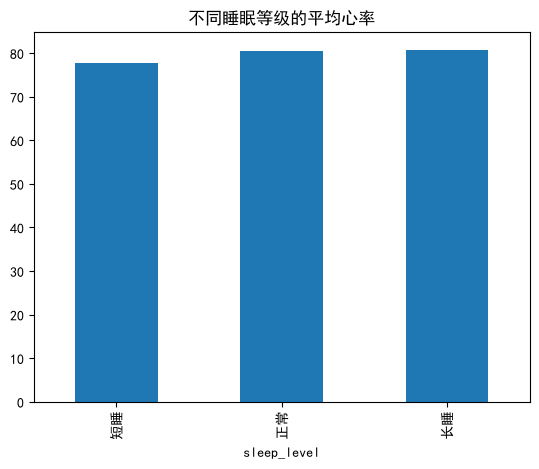

In [3]:
import pandas as pd
df = pd.read_csv('data/sleep.csv')

# 1. 填充空值
df['sleep_disorder'] = df['sleep_disorder'].fillna('Unknown')

# 2. 字符串拆列
df[['bph', 'bpl']] = df['blood_pressure'].str.split('/', expand=True).astype('int64')

# 3. 数值分箱
df['sleep_level'] = pd.cut(df['sleep_duration'], bins=[0, 6, 8, 24], labels=['短睡', '正常', '长睡'])

# 4. 分组聚合
print(df.groupby('sleep_level')[['sleep_quality', 'heart_rate']].agg('mean'))

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows电脑用黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题
import matplotlib.pyplot as plt
result = df.groupby('sleep_level')['heart_rate'].mean()
result.plot(kind='bar', title='不同睡眠等级的平均心率')
plt.savefig('图.png') # 这一句就是存图片
